In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy
from scipy.odr import ODR, Model, RealData


In [24]:
df = pd.read_excel("data/OPA.xlsx", sheet_name="A5")

df.head(10)


,Pos. Schirm [cm],Linse links (cm),Bild links (cm),Anzahl links,Linse rechts (cm),Bild rechts (mm),Anzahl rechts
0,145,34.2,3.9,1,NaN,NaN,NaN
1,140,34.4,3.7,1,NaN,NaN,NaN
2,135,34.4,3.5,1,NaN,NaN,NaN
3,130,34.5,3.3,1,NaN,NaN,NaN
4,125,34.7,3.1,1,NaN,NaN,NaN
5,120,34.9,2.8,1,NaN,NaN,NaN
6,115,34.9,2.7,1,101.2,3.0,3.0
7,110,35.5,2.5,1,90.3,5.0,5.0
8,105,35.4,2.2,1,80.8,6.0,5.0
9,100,35.7,2.1,1,85.6,7.0,5.0


In [25]:
df.rename(columns={'Pos. Schirm [cm]': 'Pos. Schirm [mm]',
                   'Linse links (cm)': 'Linse links (mm)',
                   'Bild links (cm)': 'Bild links (mm)',
                   'Linse rechts (cm)': 'Linse rechts (mm)'}, inplace=True)
df['Pos. Schirm [mm]'] *= 10
df['Linse links (mm)'] *= 10
df['Bild links (mm)'] *= 10
df['Linse rechts (mm)'] *= 10

In [26]:
df["Pos_Schirm_u"] = df["Pos. Schirm [mm]"].apply(lambda x: ufloat(x, 1))

df["Linse_Links_u"] = df["Linse links (mm)"].apply(lambda x: ufloat(x, 1))
df["Linse_Rechts_u"] = df["Linse rechts (mm)"].apply(
    lambda x: ufloat(x, 1) if pd.notnull(x) else np.nan
)

In [27]:
# Kartesisches Koordinatensystem:
#   Ursprung = Referenzmarke (Mitte des Linsensystems)
#   Positiv = Richtung zum Schirm (rechts der Linse)
#   Negativ = Richtung zur Lampe (links der Linse)
#   => g < 0 (Gegenstand links), g' > 0 (Bild rechts)
#   => β < 0 (invertiertes Bild)
#   => Linsengleichung: 1/f' = 1/g' - 1/g

u_pos = 1  # mm Positionsunsicherheit (Ablesegenauigkeit Lineal/Schiene)
u_bild_links = 1  # mm Unsicherheit Bildgröße
u_bild_rechts = 0.5

pos_gegenstand = ufloat(180, u_pos)  # mm Position des Gegenstands auf der Schiene
groesse_gegenstand = ufloat(29.6 / 6, 0.05 / 6)  # mm (6 Kästchen = 29.6 mm ± 0.05 mm)
d_linsen = 30.0  # mm Abstand Linse G - Linse E (keine eigene Unsicherheit)

print(f"Gegenstandsposition: {pos_gegenstand} mm")
print(f"Gegenstandsgröße: {groesse_gegenstand} mm")


Gegenstandsposition: 180.0+/-1.0 mm
Gegenstandsgröße: 4.933+/-0.008 mm


In [28]:
# Für die linke Linse
df["Linse Links [mm]"] = df["Linse links (mm)"].apply(lambda x: ufloat(x, u_pos))

# Für die rechte Linse (behandelt auch NaN Werte sicher)
df["Linse Rechts [mm]"] = df["Linse rechts (mm)"].apply(
    lambda x: ufloat(x, u_pos) if pd.notnull(x) else x
)

In [29]:
# Fehlerfortpflanzung passiert hier automatisch: ufloat / Zahl
df["Bild_links_u"] = df.apply(
    lambda row: ufloat(row["Bild links (mm)"], u_bild_links) / row["Anzahl links"], axis=1
)

df["Bild_rechts_u"] = df.apply(
    lambda row: ufloat(row["Bild rechts (mm)"], u_bild_rechts) / row["Anzahl rechts"]
    if pd.notnull(row["Bild rechts (mm)"]) else np.nan, axis=1
)

In [30]:
# Das Minuszeichen steht für das kopfstehende reelle Bild
df["beta_links"] = -df["Bild_links_u"] / groesse_gegenstand

df["beta_rechts"] = -df["Bild_rechts_u"] / groesse_gegenstand

In [31]:
df["g_links"] = pos_gegenstand - (df["Linse_Links_u"] + (d_linsen / 2))
df["g_strich_links"] = df["Pos_Schirm_u"] - df["Linse_Links_u"]

df["g_rechts"] = pos_gegenstand - (df["Linse_Rechts_u"] + (d_linsen / 2))
df["g_strich_rechts"] = df["Pos_Schirm_u"] - df["Linse_Rechts_u"]

In [32]:
# x = 1 - 1/beta für den g-Plot
df["abbe_x_g_links"] = 1 - (1 / df["beta_links"])
df["abbe_x_g_rechts"] = 1 - (1 / df["beta_rechts"])

# x' = 1 - beta für den g'-Plot
df["abbe_x_g_strich_links"] = 1 - df["beta_links"]
df["abbe_x_g_strich_rechts"] = 1 - df["beta_rechts"]

In [33]:
df

,Pos. Schirm [mm],Linse links (mm),Bild links (mm),Anzahl links,Linse rechts (mm),Bild rechts (mm),Anzahl rechts,Pos_Schirm_u,Linse_Links_u,Linse_Rechts_u,...,beta_links,beta_rechts,g_links,g_strich_links,g_rechts,g_strich_rechts,abbe_x_g_links,abbe_x_g_rechts,abbe_x_g_strich_links,abbe_x_g_strich_rechts
0,1450,342.0,39.0,1,NaN,NaN,NaN,1450.0+/-1.0,342.0+/-1.0,NaN,...,-7.91+/-0.20,nan+/-nan,-177.0+/-1.4,1108.0+/-1.4,nan+/-1.0,nan+/-1.0,1.1265+/-0.0033,nan+/-nan,8.91+/-0.20,nan+/-nan
1,1400,344.0,37.0,1,NaN,NaN,NaN,1400.0+/-1.0,344.0+/-1.0,NaN,...,-7.50+/-0.20,nan+/-nan,-179.0+/-1.4,1056.0+/-1.4,nan+/-1.0,nan+/-1.0,1.133+/-0.004,nan+/-nan,8.50+/-0.20,nan+/-nan
2,1350,344.0,35.0,1,NaN,NaN,NaN,1350.0+/-1.0,344.0+/-1.0,NaN,...,-7.09+/-0.20,nan+/-nan,-179.0+/-1.4,1006.0+/-1.4,nan+/-1.0,nan+/-1.0,1.141+/-0.004,nan+/-nan,8.09+/-0.20,nan+/-nan
3,1300,345.0,33.0,1,NaN,NaN,NaN,1300.0+/-1.0,345.0+/-1.0,NaN,...,-6.69+/-0.20,nan+/-nan,-180.0+/-1.4,955.0+/-1.4,nan+/-1.0,nan+/-1.0,1.149+/-0.005,nan+/-nan,7.69+/-0.20,nan+/-nan
4,1250,347.0,31.0,1,NaN,NaN,NaN,1250.0+/-1.0,347.0+/-1.0,NaN,...,-6.28+/-0.20,nan+/-nan,-182.0+/-1.4,903.0+/-1.4,nan+/-1.0,nan+/-1.0,1.159+/-0.005,nan+/-nan,7.28+/-0.20,nan+/-nan
5,1200,349.0,28.0,1,NaN,NaN,NaN,1200.0+/-1.0,349.0+/-1.0,NaN,...,-5.68+/-0.20,nan+/-nan,-184.0+/-1.4,851.0+/-1.4,nan+/-1.0,nan+/-1.0,1.176+/-0.006,nan+/-nan,6.68+/-0.20,nan+/-nan
6,1150,349.0,27.0,1,1012.0,3.0,3.0,1150.0+/-1.0,349.0+/-1.0,1012.0+/-1.0,...,-5.47+/-0.20,-0.203+/-0.034,-184.0+/-1.4,801.0+/-1.4,-847.0+/-1.4,138.0+/-1.4,1.183+/-0.007,5.9+/-0.8,6.47+/-0.20,1.203+/-0.034
7,1100,355.0,25.0,1,903.0,5.0,5.0,1100.0+/-1.0,355.0+/-1.0,903.0+/-1.0,...,-5.07+/-0.20,-0.203+/-0.020,-190.0+/-1.4,745.0+/-1.4,-738.0+/-1.4,197.0+/-1.4,1.197+/-0.008,5.9+/-0.5,6.07+/-0.20,1.203+/-0.020
8,1050,354.0,22.0,1,808.0,6.0,5.0,1050.0+/-1.0,354.0+/-1.0,808.0+/-1.0,...,-4.46+/-0.20,-0.243+/-0.020,-189.0+/-1.4,696.0+/-1.4,-643.0+/-1.4,242.0+/-1.4,1.224+/-0.010,5.11+/-0.34,5.46+/-0.20,1.243+/-0.020
9,1000,357.0,21.0,1,856.0,7.0,5.0,1000.0+/-1.0,357.0+/-1.0,856.0+/-1.0,...,-4.26+/-0.20,-0.284+/-0.020,-192.0+/-1.4,643.0+/-1.4,-691.0+/-1.4,144.0+/-1.4,1.235+/-0.011,4.52+/-0.25,5.26+/-0.20,1.284+/-0.020


In [34]:
df["check_beta"] = df["beta_links"] * df["beta_rechts"]

In [35]:
df[["Pos. Schirm [mm]", "beta_links", "beta_rechts", "check_beta", "g_rechts"]]

,Pos. Schirm [mm],beta_links,beta_rechts,check_beta,g_rechts
0,1450,-7.91+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
1,1400,-7.50+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
2,1350,-7.09+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
3,1300,-6.69+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
4,1250,-6.28+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
5,1200,-5.68+/-0.20,nan+/-nan,nan+/-nan,nan+/-1.0
6,1150,-5.47+/-0.20,-0.203+/-0.034,1.11+/-0.19,-847.0+/-1.4
7,1100,-5.07+/-0.20,-0.203+/-0.020,1.03+/-0.11,-738.0+/-1.4
8,1050,-4.46+/-0.20,-0.243+/-0.020,1.08+/-0.10,-643.0+/-1.4
9,1000,-4.26+/-0.20,-0.284+/-0.020,1.21+/-0.10,-691.0+/-1.4


In [36]:
from scipy.odr import ODR, Model, RealData
import numpy as np
import math


# Lineares Modell für ODR definieren (y = B[0]*x + B[1])
def linear_func(B, x):
    return B[0] * x + B[1]


linear_model = Model(linear_func)


# --- KUGELSICHERE Hilfsfunktion zum Extrahieren ---
def extract_vals(series):
    noms, stds = [], []
    for val in series:
        # Prüfen ob der Wert überhaupt existiert und ein ufloat ist
        if pd.notnull(val):
            try:
                # Prüfen ob der Nominalwert eine gültige Zahl ist (kein NaN)
                if not math.isnan(val.n):
                    noms.append(val.n)
                    # Falls der Fehler 0 sein sollte, setze ein Minimum,
                    # da ODR bei Division durch 0 abstürzt
                    err = val.s if val.s > 0 else 1e-5
                    stds.append(err)
            except AttributeError:
                pass
    return np.array(noms, dtype=float), np.array(stds, dtype=float)


# --- Daten extrahieren ---
# Links (Vergrößert)
x_g_L_nom, x_g_L_err = extract_vals(df["abbe_x_g_links"])
y_g_L_nom, y_g_L_err = extract_vals(df["g_links"])
x_gp_L_nom, x_gp_L_err = extract_vals(df["abbe_x_g_strich_links"])
y_gp_L_nom, y_gp_L_err = extract_vals(df["g_strich_links"])

# Rechts (Verkleinert)
x_g_R_nom, x_g_R_err = extract_vals(df["abbe_x_g_rechts"])
y_g_R_nom, y_g_R_err = extract_vals(df["g_rechts"])
x_gp_R_nom, x_gp_R_err = extract_vals(df["abbe_x_g_strich_rechts"])
y_gp_R_nom, y_gp_R_err = extract_vals(df["g_strich_rechts"])

# --- ALLE Daten für den Fit zusammenführen ---
x_g_all_nom = np.concatenate([x_g_L_nom, x_g_R_nom])
x_g_all_err = np.concatenate([x_g_L_err, x_g_R_err])
y_g_all_nom = np.concatenate([y_g_L_nom, y_g_R_nom])
y_g_all_err = np.concatenate([y_g_L_err, y_g_R_err])

x_gp_all_nom = np.concatenate([x_gp_L_nom, x_gp_R_nom])
x_gp_all_err = np.concatenate([x_gp_L_err, x_gp_R_err])
y_gp_all_nom = np.concatenate([y_gp_L_nom, y_gp_R_nom])
y_gp_all_err = np.concatenate([y_gp_L_err, y_gp_R_err])

# --- Fit 1: g vs (1 - 1/beta) (Alle Daten) ---
# WICHTIG: beta0 MUSS Floats enthalten!
data_g = RealData(x_g_all_nom, y_g_all_nom, sx=x_g_all_err, sy=y_g_all_err)
odr_g = ODR(data_g, linear_model, beta0=[-150.0, -50.0])
out_g = odr_g.run()

f_g_val = out_g.beta[0]
f_g_err = out_g.sd_beta[0]
h1_val = out_g.beta[1]
h1_err = out_g.sd_beta[1]

# --- Fit 2: g' vs (1 - beta) (Alle Daten) ---
data_gp = RealData(x_gp_all_nom, y_gp_all_nom, sx=x_gp_all_err, sy=y_gp_all_err)
odr_gp = ODR(data_gp, linear_model, beta0=[150.0, -50.0])
out_gp = odr_gp.run()

f_gp_val = out_gp.beta[0]
f_gp_err = out_gp.sd_beta[0]
h2_val = out_gp.beta[1]
h2_err = out_gp.sd_beta[1]

print("=== Ergebnisse des ODR-Fits (ALLE Abbildungen) ===")
print(f"Stop-Grund Fit 1: {out_g.stopreason[0]}")  # Zur Sicherheit!
print(f"Aus g-Plot:  f = {f_g_val:.1f} +/- {f_g_err:.1f} mm  => f' = {-f_g_val:.1f} mm")
print(f"Aus g'-Plot: f' = {f_gp_val:.1f} +/- {f_gp_err:.1f} mm")
print(f"Hauptebene 1 (h1) = {h1_val:.1f} +/- {h1_err:.1f} mm")
print(f"Hauptebene 2 (h2) = {h2_val:.1f} +/- {h2_err:.1f} mm")
print(f"Hauptebenenabstand h = h2 - h1 = {(h2_val - h1_val):.1f} mm")

=== Ergebnisse des ODR-Fits (ALLE Abbildungen) ===
Stop-Grund Fit 1: Sum of squares convergence
Aus g-Plot:  f = -139.6 +/- 3.1 mm  => f' = 139.6 mm
Aus g'-Plot: f' = 129.8 +/- 9.9 mm
Hauptebene 1 (h1) = -20.4 +/- 3.8 mm
Hauptebene 2 (h2) = 0.3 +/- 16.8 mm
Hauptebenenabstand h = h2 - h1 = 20.7 mm


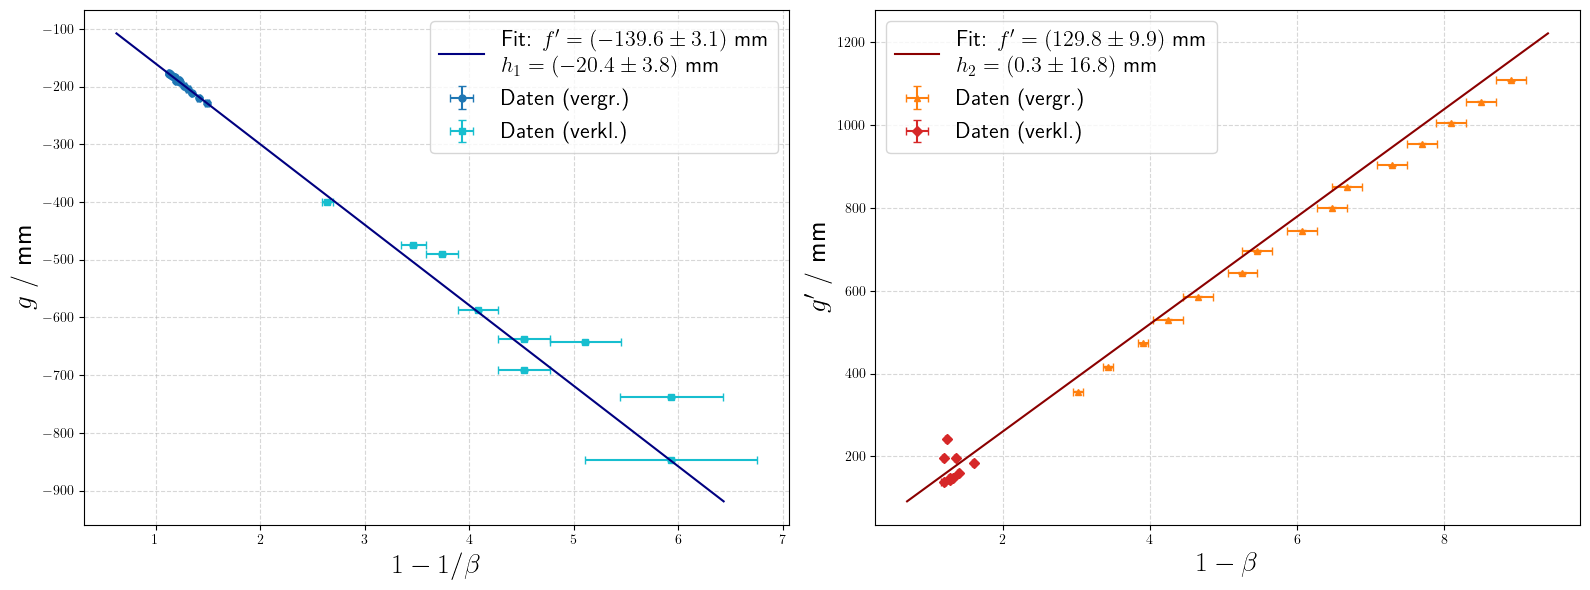

In [37]:
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== Plot 1: g vs (1 - 1/β) =====
ax1.errorbar(x_g_L_nom, y_g_L_nom, xerr=x_g_L_err, yerr=y_g_L_err,
             fmt='o', color='tab:blue', capsize=3, markersize=5,
             label=r'Daten (vergr.)')

if len(x_g_R_nom) > 0:
    ax1.errorbar(x_g_R_nom, y_g_R_nom, xerr=x_g_R_err, yerr=y_g_R_err,
                 fmt='s', color='tab:cyan', capsize=3, markersize=5,
                 label=r'Daten (verkl.)')

x_fit_g = np.linspace(min(x_g_all_nom) - 0.5, max(x_g_all_nom) + 0.5, 100)
ax1.plot(x_fit_g, linear_func(out_g.beta, x_fit_g), color='navy', linestyle='-', zorder=5,
         label=f"Fit: $f' = ({f_g_val:.1f} \\pm {f_g_err:.1f})$ mm\n$h_1 = ({h1_val:.1f} \\pm {h1_err:.1f})$ mm")

ax1.set_xlabel(r'$1 - 1/\beta$', fontsize=20, fontweight='bold')
ax1.set_ylabel(r'$g$ / mm', fontsize=20, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='best', fontsize=16)

# ===== Plot 2: g' vs (1 - β) =====
ax2.errorbar(x_gp_L_nom, y_gp_L_nom, xerr=x_gp_L_err, yerr=y_gp_L_err,
             fmt='^', color='tab:orange', capsize=3, markersize=5,
             label=r'Daten (vergr.)')

if len(x_gp_R_nom) > 0:
    ax2.errorbar(x_gp_R_nom, y_gp_R_nom, xerr=x_gp_R_err, yerr=y_gp_R_err,
                 fmt='D', color='tab:red', capsize=3, markersize=5,
                 label=r'Daten (verkl.)')

x_fit_gp = np.linspace(min(x_gp_all_nom) - 0.5, max(x_gp_all_nom) + 0.5, 100)
ax2.plot(x_fit_gp, linear_func(out_gp.beta, x_fit_gp), color='darkred', linestyle='-', zorder=5,
         label=f"Fit: $f' = ({f_gp_val:.1f} \\pm {f_gp_err:.1f})$ mm\n$h_2 = ({h2_val:.1f} \\pm {h2_err:.1f})$ mm")

ax2.set_xlabel(r'$1 - \beta$', fontsize=20, fontweight='bold')
ax2.set_ylabel(r"$g'$ / mm", fontsize=20, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='best', fontsize=16)

plt.tight_layout()
 # save as svg
plt.savefig("abbe_plots.svg", format='svg', bbox_inches='tight', dpi=150)

In [38]:
# calculate f mean and abstand der hauotebnen
f_mean = (-f_g_val + f_gp_val) / 2
f_mean_err = np.sqrt(f_g_err**2 + f_gp_err**2) / 2
h_abstand = h2_val - h1_val
h_abstand_err = np.sqrt(h1_err**2 + h2_err**2)
print(f"Mittlere Brennweite f = {f_mean:.1f} +/- {f_mean_err:.1f} mm")
print(f"Hauptebenenabstand h = {h_abstand:.1f} +/- {h_abstand_err:.1f} mm")

Mittlere Brennweite f = 134.7 +/- 5.2 mm
Hauptebenenabstand h = 20.7 +/- 17.2 mm


In [39]:
# ============================================================
# Aufgabe 7: Brennweite der Zerstreuungslinse f'_E
# ============================================================
# Mittelwert der Brennweite der Sammellinse G aus Aufgabe 4
f_G = (ufloat(73.6, 0.7) + ufloat(73.9, 0.6)) / 2
print(f"Brennweite Sammellinse G:  f'_G = {f_G} mm")

# Brennweite des Gesamtsystems aus Aufgabe 5 (Abbe-Methode) als gewichtetes Mittel der beiden Fits
# f_g_val ist negativ (Steigung des g-Plots), f_gp_val ist positiv
f_sys = (ufloat(-f_g_val, f_g_err) / f_g_err**2 + ufloat(f_gp_val, f_gp_err) / f_gp_err**2) / (1 / f_g_err**2 + 1 / f_gp_err**2)
print(f"Brennweite Gesamtsystem:   f'   = {f_sys} mm")

# Linsenabstand
t = 30  # mm

# Gleichung (6): 1/f' = 1/f'_G + 1/f'_E - t/(f'_G * f'_E)
# Umgestellt nach f'_E:
#   1/f'_E * (1 - t/f'_G) = 1/f' - 1/f'_G
#   1/f'_E = (1/f' - 1/f'_G) / (1 - t/f'_G)
#   f'_E = (1 - t/f'_G) / (1/f' - 1/f'_G)
f_E = (1 - t / f_G) / (1 / f_sys - 1 / f_G)

print(f"\n=== Aufgabe 7: Brennweite der Zerstreuungslinse ===")
print(f"f'_E = {f_E:.1f} mm")
print(f"Herstellerangabe: f'_E = -100 mm")
abw = abs(f_E.n - (-100)) / abs(f_E.s)
print(f"Abweichung: {abs(f_E.n - (-100)):.1f} mm = {abw:.1f} σ")

Brennweite Sammellinse G:  f'_G = 73.8+/-0.5 mm
Brennweite Gesamtsystem:   f'   = 138.8+/-2.9 mm

=== Aufgabe 7: Brennweite der Zerstreuungslinse ===
f'_E = -93.4+/-2.8 mm
Herstellerangabe: f'_E = -100 mm
Abweichung: 6.6 mm = 2.4 σ


In [40]:
# ============================================================
# Aufgabe 8: Lage der Hauptebenen (Gl. 7 & 8)
# ============================================================
# Theoretische Vorgaben
f_E_hersteller = -100.0  # mm (Zerstreuungslinse)
f_G = 74.0               # mm (Sammellinse - Wert aus deinen vorherigen Daten)
t = 30.0                 # mm (Abstand)

# 1. Optische Tubuslänge (Gl. 5) berechnen
# Delta = t - f'_1 - f'_2
delta = t - f_G - f_E_hersteller

# 2. Hauptebenen relativ zu den Einzellinsen (Gl. 7)
# z = f_1 * t / Delta (Achtung: f_1 = -f'_1, daher -f_G)
z_theo = (-f_G * t) / delta
# z' = f'_2 * t / Delta
z_prime_theo = (f_E_hersteller * t) / delta

# 3. Hauptebenenabstand (Gl. 8)
h_calc = (t**2) / delta

# 4. Koordinatentransformation für den Abbe-Vergleich!
# Abbe-Referenz E lag in der Mitte.
# Linse G steht bei -t/2 (-15 mm), Linse E bei +t/2 (+15 mm)
h1_theo = z_theo - (t / 2)
h2_theo = z_prime_theo + (t / 2)

print("=== Aufgabe 8: Theoretische Lage der Hauptebenen ===")
print(f"Optische Tubuslänge Δ = {delta:.1f} mm")
print(f"z  (H relativ zu Linse G)  = {z_theo:.1f} mm")
print(f"z' (H' relativ zu Linse E) = {z_prime_theo:.1f} mm")
print(f"Theoretischer Hauptebenenabstand h (Gl. 8) = {h_calc:.1f} mm\n")

print("--- Koordinatentransformation auf Systemmitte (für Abbe-Vergleich) ---")
print(f"h_1_theo (relativ zur Mitte) = {h1_theo:.1f} mm")
print(f"h_2_theo (relativ zur Mitte) = {h2_theo:.1f} mm\n")

print(f"--- Finaler Vergleich mit Abbe-Methode (Aufgabe 5) ---")
# Wir nehmen an, dass h1_val und h2_val aus deinem ODR-Fit kommen
h1_abbe = ufloat(h1_val, h1_err)
h2_abbe = ufloat(h2_val, h2_err)

print(f"h_1:  Abbe = {h1_abbe:.1f} mm   |  Theorie = {h1_theo:.1f} mm")
print(f"h_2:  Abbe = {h2_abbe:.1f} mm   |  Theorie = {h2_theo:.1f} mm")
print(f"Δh :  Abbe = {(h2_abbe - h1_abbe):.1f} mm   |  Theorie = {h_calc:.1f} mm")

=== Aufgabe 8: Theoretische Lage der Hauptebenen ===
Optische Tubuslänge Δ = 56.0 mm
z  (H relativ zu Linse G)  = -39.6 mm
z' (H' relativ zu Linse E) = -53.6 mm
Theoretischer Hauptebenenabstand h (Gl. 8) = 16.1 mm

--- Koordinatentransformation auf Systemmitte (für Abbe-Vergleich) ---
h_1_theo (relativ zur Mitte) = -54.6 mm
h_2_theo (relativ zur Mitte) = -38.6 mm

--- Finaler Vergleich mit Abbe-Methode (Aufgabe 5) ---
h_1:  Abbe = -20.4+/-3.8 mm   |  Theorie = -54.6 mm
h_2:  Abbe = 0.3+/-16.8 mm   |  Theorie = -38.6 mm
Δh :  Abbe = 20.7+/-17.2 mm   |  Theorie = 16.1 mm


In [ ]:
'